This notebook explores some basic parts of the data, and examines the ALGO asset mor eclosely. As it has a higher position limit, and lower trading costs, it could serve as a benchmark asset for the other assets.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2281/3858623658.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_prices = pd.read_csv("prices.txt", delim_whitespace=True)


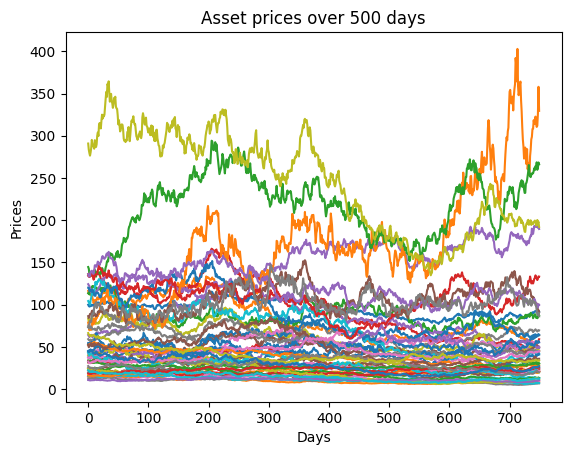

In [2]:
# Load in data 
df_prices = pd.read_csv("prices.txt", delim_whitespace=True)

# Calculate returns
df_returns = df_prices.pct_change()

# Plot the prices of all assets of the 500 days
plt.plot(df_prices)
plt.title("Asset prices over 500 days")
plt.xlabel("Days")
plt.ylabel("Prices")
plt.show()

# Correlation with ALGO
A strong correlation of returns between ALGO and the rest of the market is observed, both on an absolute and rolling basis. 

--- Benchmark Analysis for ALGO ---
Correlation with the rest of the market: 0.9857
Conclusion: Strong evidence it acts as a benchmark/index.

--- Top 5 Assets Most Correlated with ALGO ---
ILVX    0.612384
CUBO    0.550801
BENI    0.541635
SRNA    0.533220
BLBT    0.531273
Name: ALGO, dtype: float64

--- Top 5 Assets Least Correlated with ALGO ---
FARS    0.370057
HRND    0.364588
ALUT    0.359470
ULXY    0.359284
RTTH    0.341089
Name: ALGO, dtype: float64


/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2281/2385321252.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


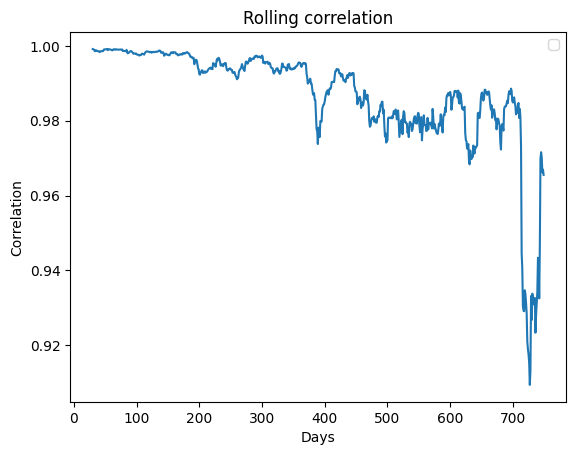

In [5]:


# Create an equal-weighted "Market Index" of the OTHER 49 assets
benchmark_ticker = "ALGO"
other_assets_returns = df_returns.drop(columns=[benchmark_ticker]) # returns of all other assets
market_average_returns = other_assets_returns.mean(axis=1) # average return. Over all 500 days


# 3. Calculate the correlation between ALGO and the Market Index
market_corr = df_returns[benchmark_ticker].corr(market_average_returns)
    
# Calculate rolling correlation
rolling_corr = df_returns[benchmark_ticker].rolling(window=30).corr(market_average_returns)
    
print(f"--- Benchmark Analysis for {benchmark_ticker} ---")
print(f"Correlation with the rest of the market: {market_corr:.4f}")
    
if market_corr > 0.75:
    print("Conclusion: Strong evidence it acts as a benchmark/index.")
elif market_corr > 0.50:
    print("Conclusion: Moderate correlation; it captures some market factor but isn't a perfect index.")
else:
    print("Conclusion: Weak correlation; it behaves like an independent asset, not a benchmark.")

# 4. Find the best candidates for pairs trading / hedging
correlations = df_returns.corr()[benchmark_ticker].sort_values(ascending=False)
    
print(f"\n--- Top 5 Assets Most Correlated with {benchmark_ticker} ---")
print(correlations.head(6)[1:]) # Skip the 1.0 correlation with itself
    
print(f"\n--- Top 5 Assets Least Correlated with {benchmark_ticker} ---")
print(correlations.tail(5))
    
# Plot rolling correlation
plt.plot(rolling_corr)
plt.title("Rolling correlation")
plt.ylabel("Correlation")
plt.xlabel("Days")
plt.legend()
plt.show()



With a shift of the market's returns a day forwards, the correlation breaks down to weak levels. Hence, the market does nto provide a signal for the movements of ALGO, instead ALGO acts as an index for the market that we can hedge our portfolio against. 

/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2281/2195362834.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


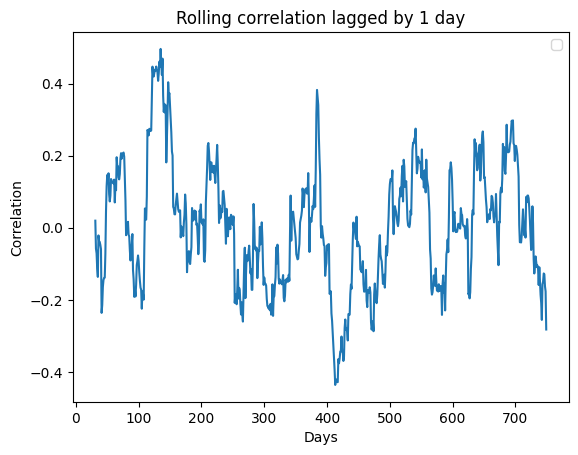

In [7]:
rolling_corr_lagged = df_returns[benchmark_ticker].rolling(window=30).corr(market_average_returns.shift(periods=1))

# Plot rolling correlation
plt.plot(rolling_corr_lagged)
plt.title("Rolling correlation lagged by 1 day")
plt.ylabel("Correlation")
plt.xlabel("Days")
plt.legend()
plt.show()

# Creating a basket 
Use a ridge regression to create a basket of stocks, instead of an equal weighting. This will improve the correlation between ALGO and the basket, and improve trading decisions.

In [10]:
from sklearn.linear_model import Ridge

# Ridge regression function
def ridge_basket(other_returns, target_returns, alpha = 1.0):
  model = Ridge(alpha=alpha).fit(other_returns, target_returns)
  
  return model.coef_, model.intercept_


# Modifying data frame
target_ticker = "ALGO"
other_cols = [c for c in df_returns if c != target_ticker]

n = len(df_returns)
split = int(n * 0.7) # Use 70% of data for training
train_df = df_returns.iloc[:split].dropna()  # First 70% of data
test_df = df_returns.iloc[split:].dropna()   # Last 30% of data

def eval_basket(basket_train, basket_test, name):
  tr = np.corrcoef(basket_train, train_df[target_ticker])[0, 1]
  te = np.corrcoef(basket_test, test_df[target_ticker])[0, 1]
  
  print(f"{name:25s} train_corr={tr:.4f}  test_corr={te:.4f}  gap={tr - te:+.4f}")

  
# Train and test split for predictors and target
Xtr, Xte = train_df[other_cols].values, test_df[other_cols].values
Ytr, Yte = train_df[target_ticker].values, test_df[target_ticker].values

# Run ridge regession
coef, intercept = ridge_basket(Xtr, Ytr, alpha = 1.0)
eval_basket(Xtr @ coef + intercept, Xte @ coef + intercept, "Ridge (alpha = 1.0)")

Ridge (alpha = 1.0)       train_corr=0.9951  test_corr=0.9826  gap=+0.0126
